In [14]:
# AFM slice/config correspondence notebook
# This notebook overlays top-layer atom positions onto one AFM 2D slice.

In [15]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path('.')
CONFIG_ID = 0        # default one configuration
SLICE_IDX = 7        # default one selected slice (0-14)
Z_THRESHOLD = 4.85   # top-layer threshold above top Au surface (A)
ATOM_MODE = 'all'    # 'all', 'O', 'H'
INVERT_Y = True      # toggle if overlay appears vertically mirrored
ROTATE_DEG = -90     # rotate display: -90 (clockwise), 0, 90, 180
SAVE_FIG = True
OUT_DIR = DATA_DIR / 'overlay_outputs'

ATOMIC_NUM_TO_SYMBOL = {1: 'H', 8: 'O', 29: 'Cu', 79: 'Au'}
SYMBOL_TO_COLOR = {'O': '#ff0000', 'H': '#ffffff', 'Cu': '#f6c343', 'Au': '#66e26f'}
MARKER_SIZE = 34


def _parse_float_list(text: str):
    # Support either space-separated or comma-separated numeric fields.
    tokens = [t for t in re.split(r'[\s,]+', text.strip()) if t]
    return np.array([float(v) for v in tokens], dtype=float)


def parse_xyz_metadata(comment_line: str):
    pattern = (
        r"Scan window:\s*\[\[([^\]]+)\],\s*\[([^\]]+)\]\]"
        r"(?:,\s*Amplitude:\s*([^,]+))?"
        r"(?:,\s*tip R0:\s*\[([^\]]+)\])?"
        r"(?:,\s*kxy:\s*([^,\]]+))?"
    )
    m = re.search(pattern, comment_line)
    if not m:
        raise ValueError(f'Cannot parse metadata from comment line: {comment_line}')

    xyz_min = _parse_float_list(m.group(1))
    xyz_max = _parse_float_list(m.group(2))
    amplitude = float(m.group(3)) if m.group(3) is not None else None
    tip_r0 = _parse_float_list(m.group(4)) if m.group(4) is not None else None
    kxy = float(m.group(5)) if m.group(5) is not None else None

    return {
        'xyz_min': xyz_min,
        'xyz_max': xyz_max,
        'amplitude': amplitude,
        'tip_r0': tip_r0,
        'kxy': kxy,
    }


def load_xyz(file_path: Path):
    lines = file_path.read_text().splitlines()
    if len(lines) < 3:
        raise ValueError(f'Invalid XYZ file (too short): {file_path}')

    n_atoms = int(lines[0].strip())
    comment = lines[1].strip()
    rows = lines[2:2 + n_atoms]
    if len(rows) != n_atoms:
        raise ValueError(f'Atom count mismatch in {file_path}: expected {n_atoms}, got {len(rows)}')

    atomic_numbers = []
    positions = []
    for row in rows:
        parts = row.split()
        if len(parts) < 4:
            continue
        atomic_numbers.append(int(parts[0]))
        positions.append([float(parts[1]), float(parts[2]), float(parts[3])])

    atomic_numbers = np.array(atomic_numbers, dtype=int)
    positions = np.array(positions, dtype=float)
    metadata = parse_xyz_metadata(comment)
    symbols = np.array([ATOMIC_NUM_TO_SYMBOL.get(z, f'Z{z}') for z in atomic_numbers])

    return {
        'atomic_numbers': atomic_numbers,
        'symbols': symbols,
        'positions': positions,
        'metadata': metadata,
        'comment': comment,
    }


def load_slice_image(config_id: int, slice_idx: int, data_dir: Path):
    img_path = data_dir / f'{config_id}.{slice_idx:02d}.png'
    if not img_path.exists():
        raise FileNotFoundError(f'Missing AFM slice image: {img_path}')
    img = Image.open(img_path).convert('L')
    arr = np.array(img, dtype=float)
    return arr, img_path


def select_top_layer(symbols: np.ndarray, positions: np.ndarray, z_threshold: float, atom_mode: str = 'all'):
    is_au = symbols == 'Au'
    if not np.any(is_au):
        raise ValueError('No Au atoms found; cannot define Au reference surface.')

    au_top_z = positions[is_au, 2].max()
    is_top = positions[:, 2] > (au_top_z + z_threshold)

    if atom_mode == 'O':
        is_top &= (symbols == 'O')
    elif atom_mode == 'H':
        is_top &= (symbols == 'H')
    elif atom_mode != 'all':
        raise ValueError("atom_mode must be one of: 'all', 'O', 'H'")

    return is_top, au_top_z


def map_xy_to_pixels(x, y, xyz_min, xyz_max, width, height, invert_y=True):
    x_norm = (x - xyz_min[0]) / (xyz_max[0] - xyz_min[0])
    y_norm = (y - xyz_min[1]) / (xyz_max[1] - xyz_min[1])

    px = np.clip(x_norm * (width - 1), 0, width - 1)
    py = np.clip((1.0 - y_norm if invert_y else y_norm) * (height - 1), 0, height - 1)
    return px, py


def rotate_image_and_points(img, px, py, rotate_deg):
    if rotate_deg not in (-90, 0, 90, 180):
        raise ValueError('rotate_deg must be one of: -90, 0, 90, 180')

    h, w = img.shape
    if rotate_deg == 0:
        return img, px, py
    if rotate_deg == -90:
        img_r = np.rot90(img, k=-1)
        px_r = (h - 1) - py
        py_r = px
        return img_r, px_r, py_r
    if rotate_deg == 90:
        img_r = np.rot90(img, k=1)
        px_r = py
        py_r = (w - 1) - px
        return img_r, px_r, py_r

    img_r = np.rot90(img, k=2)
    px_r = (w - 1) - px
    py_r = (h - 1) - py
    return img_r, px_r, py_r

Config: 0
XYZ file: 0.xyz
Scan window min: [ 0.88146708 -5.72912762 16.91619644], max: [32.75646708 26.14587238 19.81619644]
Amplitude: 1.4999999999999845, tip R0: [0.17162186 0.17611841 3.        ], kxy: -0.02871854044497013
Au top z: 4.711 A, z threshold: 4.850 A
Top-layer atoms (all): 42
Rotation: -90 deg
Rendering slices: 0..14
Top-layer species counts: {'H': 27, 'O': 15}
Saved: overlay_outputs/overlay_cfg00_allslices_mode-all_rot-90.png


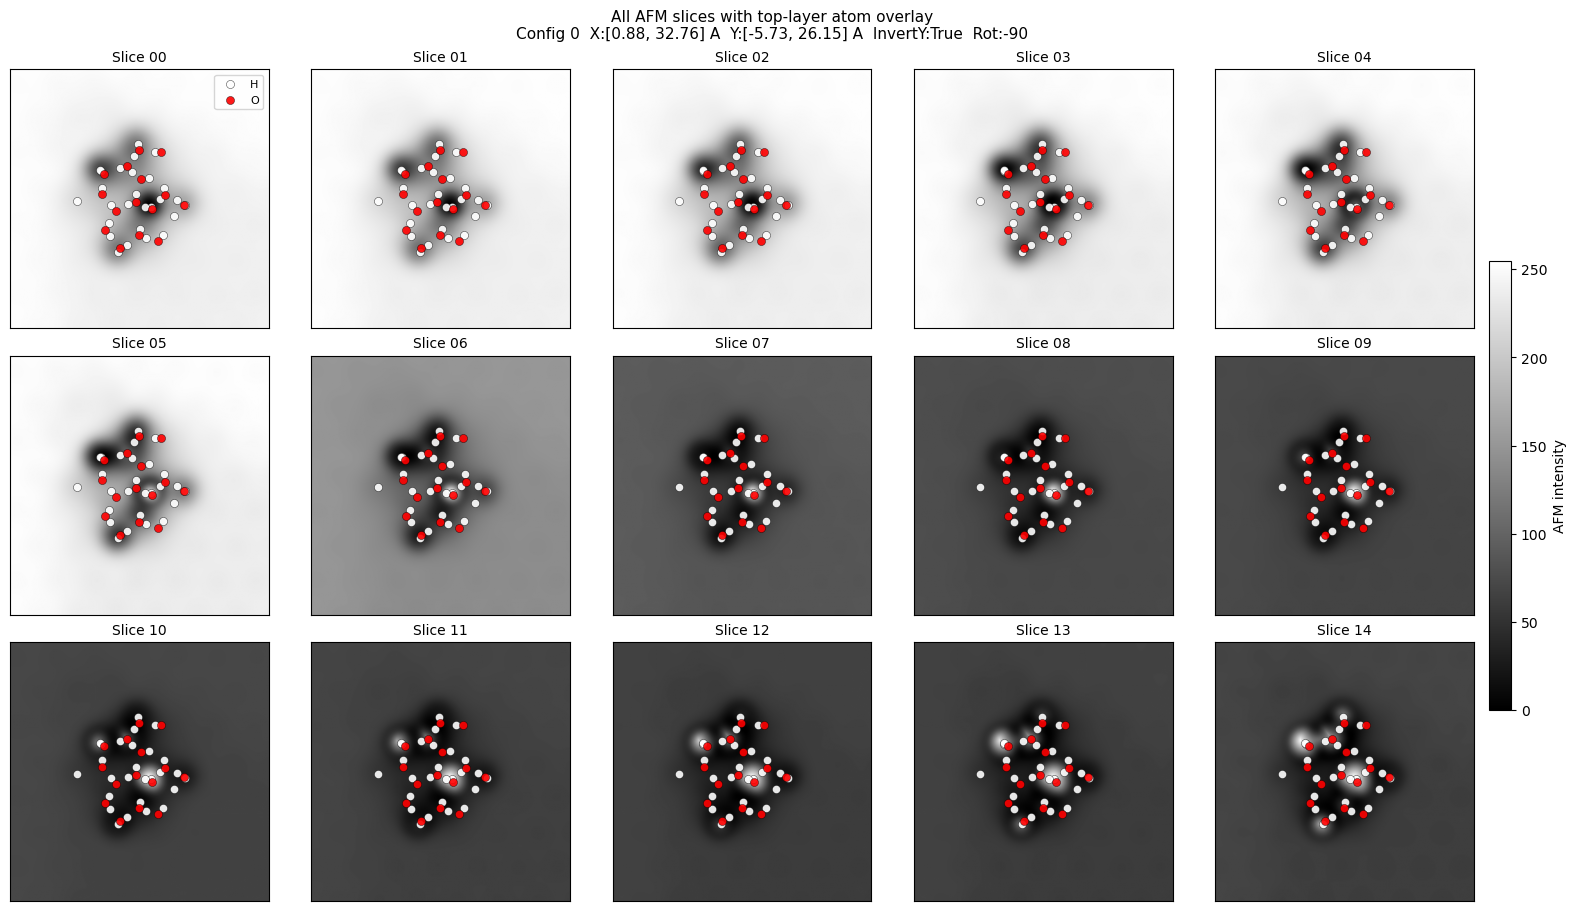

In [16]:
# 1) Load config
xyz_path = DATA_DIR / f'{CONFIG_ID}.xyz'
if not xyz_path.exists():
    raise FileNotFoundError(f'Missing XYZ file: {xyz_path}')

xyz = load_xyz(xyz_path)
symbols = xyz['symbols']
positions = xyz['positions']
meta = xyz['metadata']
xyz_min = meta['xyz_min']
xyz_max = meta['xyz_max']

# 2) Top-layer selection
is_top, au_top_z = select_top_layer(symbols, positions, Z_THRESHOLD, atom_mode=ATOM_MODE)
top_symbols = symbols[is_top]
top_pos = positions[is_top]

# 3) Prepare all slices
SLICE_LIST = list(range(15))
N_COLS = 5
N_ROWS = int(np.ceil(len(SLICE_LIST) / N_COLS))

print(f'Config: {CONFIG_ID}')
print(f'XYZ file: {xyz_path}')
print(f'Scan window min: {xyz_min}, max: {xyz_max}')
print(f'Amplitude: {meta["amplitude"]}, tip R0: {meta["tip_r0"]}, kxy: {meta["kxy"]}')
print(f'Au top z: {au_top_z:.3f} A, z threshold: {Z_THRESHOLD:.3f} A')
print(f'Top-layer atoms ({ATOM_MODE}): {top_pos.shape[0]}')
print(f'Rotation: {ROTATE_DEG} deg')
print(f'Rendering slices: {SLICE_LIST[0]}..{SLICE_LIST[-1]}')

if top_pos.shape[0] > 0:
    uniq, cnt = np.unique(top_symbols, return_counts=True)
    print('Top-layer species counts:', dict(zip(uniq.tolist(), cnt.tolist())))

# 4) Plot all slices with overlay
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(3.2 * N_COLS, 3.0 * N_ROWS), constrained_layout=True)
axes = np.array(axes).reshape(N_ROWS, N_COLS)

for i, slice_idx in enumerate(SLICE_LIST):
    r, c = divmod(i, N_COLS)
    ax = axes[r, c]

    img, img_path = load_slice_image(CONFIG_ID, slice_idx, DATA_DIR)
    height, width = img.shape

    # Map XY to pixel on this slice grid, then rotate together with image.
    px, py = map_xy_to_pixels(top_pos[:, 0], top_pos[:, 1], xyz_min, xyz_max, width, height, invert_y=INVERT_Y)
    img_plot, px_plot, py_plot = rotate_image_and_points(img, px, py, ROTATE_DEG)

    im = ax.imshow(img_plot, cmap='gray')
    if top_pos.shape[0] > 0:
        for sp in np.unique(top_symbols):
            mask = top_symbols == sp
            # Show legend only on first panel to avoid clutter.
            label = sp if i == 0 else None
            ax.scatter(
                px_plot[mask],
                py_plot[mask],
                s=MARKER_SIZE,
                c=SYMBOL_TO_COLOR.get(sp, '#ffffff'),
                edgecolors='black',
                linewidths=0.3,
                alpha=0.9,
                label=label,
            )

    ax.set_title(f'Slice {slice_idx:02d}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

    if i == 0 and top_pos.shape[0] > 0:
        ax.legend(loc='upper right', frameon=True, fontsize=8)

# Hide any unused axes (if SLICE_LIST length is not exact grid size).
for j in range(len(SLICE_LIST), N_ROWS * N_COLS):
    r, c = divmod(j, N_COLS)
    axes[r, c].axis('off')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.01)
cbar.set_label('AFM intensity', rotation=90)

extent_text = (
    f'Config {CONFIG_ID}  X:[{xyz_min[0]:.2f}, {xyz_max[0]:.2f}] A  '
    f'Y:[{xyz_min[1]:.2f}, {xyz_max[1]:.2f}] A  InvertY:{INVERT_Y}  Rot:{ROTATE_DEG}'
)
fig.suptitle(f'All AFM slices with top-layer atom overlay\n{extent_text}', fontsize=11)

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    out_png = OUT_DIR / f'overlay_cfg{CONFIG_ID:02d}_allslices_mode-{ATOM_MODE}_rot{ROTATE_DEG}.png'
    fig.savefig(out_png, dpi=180)
    print(f'Saved: {out_png}')

plt.show()

Saved: overlay_outputs/ase_structure_cfg00.png


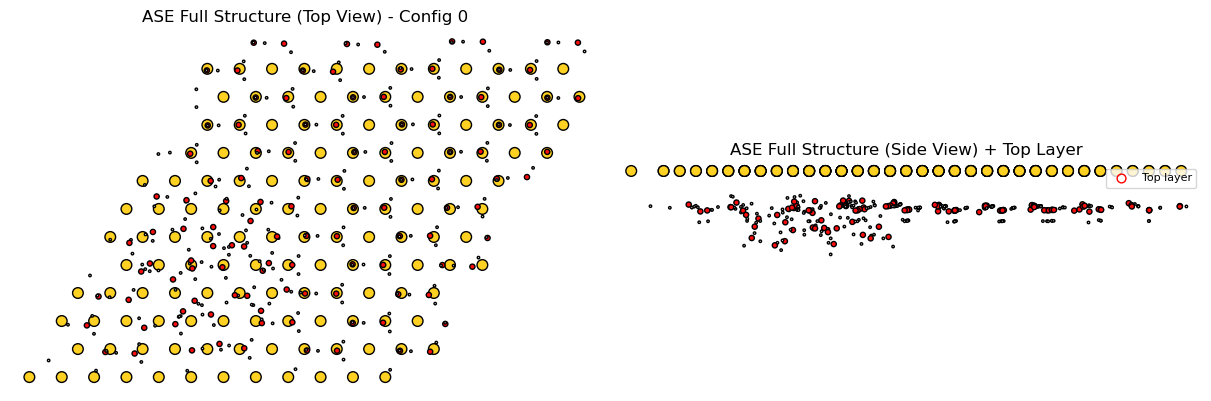

In [ ]:
# ASE structural visualization (full structure + top-layer highlight + GUI option)
from ase import Atoms
from ase.visualize import view
from ase.visualize.plot import plot_atoms

OPEN_ASE_GUI = True  # Set True to open an external ASE GUI window.

atoms_all = Atoms(symbols=symbols.tolist(), positions=positions)
atoms_top = Atoms(symbols=top_symbols.tolist(), positions=top_pos)

# Enlarge light atoms for easier visibility in static plots.
RADIUS_BY_ELEMENT = {'H': 0.55, 'O': 0.78, 'Cu': 0.65, 'Au': 0.70}
atom_radii = [RADIUS_BY_ELEMENT.get(s, 0.60) for s in atoms_all.get_chemical_symbols()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Left: top view of full structure
plot_atoms(atoms_all, axes[0], radii=atom_radii, rotation=('0x,0y,0z'))
axes[0].set_title(f'ASE Full Structure (Top View) - Config {CONFIG_ID}')
axes[0].set_axis_off()

# Right: side view, overlay top-layer atoms in red circles
plot_atoms(atoms_all, axes[1], radii=atom_radii, rotation=('90x,0y,0z'))
if len(atoms_top) > 0:
    top_xy = atoms_top.get_positions()[:, [0, 2]]
    axes[1].scatter(top_xy[:, 0], top_xy[:, 1], s=60, facecolors='none', edgecolors='red', linewidths=1.2, label='Top layer')
    axes[1].legend(loc='upper right', frameon=True, fontsize=8)
axes[1].set_title('ASE Full Structure (Side View) + Top Layer')
axes[1].set_axis_off()

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    out_ase = OUT_DIR / f'ase_structure_cfg{CONFIG_ID:02d}.png'
    fig.savefig(out_ase, dpi=180)
    print(f'Saved: {out_ase}')

plt.show()

if OPEN_ASE_GUI:
    try:
        view(atoms_all)
        print('ASE GUI launched for full structure.')
    except Exception as e:
        print(f'Could not launch ASE GUI window: {e}')
        print('Tip: use a desktop session (DISPLAY available) for external ASE GUI.')